# Tutorial 3: Generating Mock Galaxies

Before fitting real data, we validate the pipeline on synthetic observations with known ground truth. This notebook generates mock galaxies at different redshifts, burstiness levels, and noise levels -- the test bed for Tutorials 4-5.

**What you will learn:**

| Section | Topic | Key concept |
|---------|-------|-------------|
| 1 | A single mock galaxy | `generate_mock()` with known truth |
| 2 | Effect of signal-to-noise ratio | How noise degrades parameter recovery |
| 3 | A zoo of galaxy types | Archetypes spanning young/old, dusty/clean, bursty/smooth |
| 4 | A mock population | Ensemble statistics and color-color diagrams |
| 5 | Mock spectroscopy | 200 pixels vs 5 bands: breaking degeneracies |

**Prerequisite:** [Tutorial 2: From SFH to Observable SED](02_forward_model.ipynb) covers the forward model components (SSP, dust, photometry). Here we use those components as a black box to generate test data.

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, "../src")

from diffsed.utils.devices import setup_jax
setup_jax()

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.framealpha": 0.9,
})

os.makedirs("figures", exist_ok=True)

# ---- Load SSP templates ----
from diffsed.models.sps.dsps_wrapper import load_ssp_data
from diffsed.forward_model import ForwardModel, ModelConfig, generate_mock
from diffsed.models.sfh.gp_sfh import gp_from_xi, compute_sqrt_power_drw
from diffsed.models.sfh.psd_models import drw_variance
from diffsed.models.sfh.mean_sfh import double_powerlaw
from diffsed.models.observation.photometry import ab_mag_from_flux
from diffsed.utils.grid import (
    make_log_age_grid, grid_spacing, log_age_to_age_yr, log_age_to_age_gyr,
)
from diffsed.utils.cosmology import luminosity_distance

SSP_PATH = "../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
ssp_data = load_ssp_data(SSP_PATH)

# ---- SDSS-like top-hat filters ----
filter_centers = {"u": 3551, "g": 4686, "r": 6166, "i": 7480, "z": 8932}
filter_colors = {"u": "#7b3294", "g": "#008837", "r": "#d73027",
                 "i": "#fc8d59", "z": "#4d4d4d"}
band_names = ["u", "g", "r", "i", "z"]
half_w = 200.0
filter_waves = [jnp.linspace(filter_centers[b] - half_w,
                             filter_centers[b] + half_w, 50)
                for b in band_names]
filter_trans = [jnp.ones(50) for _ in band_names]
band_centers_arr = jnp.array([filter_centers[b] for b in band_names], dtype=float)

# ---- Grid setup ----
N_GRID = 256
log_age_grid = make_log_age_grid(N_GRID)
d_log_age = grid_spacing(log_age_grid)
age_yr = log_age_to_age_yr(log_age_grid)
age_gyr = log_age_to_age_gyr(log_age_grid)


def compute_sfh(params):
    """Reconstruct the full SFH from a parameter dictionary.

    Returns the SFR(t) array on the GP log-age grid (in M_sun/yr).
    """
    sqrt_p = compute_sqrt_power_drw(
        N_GRID, float(d_log_age), params["sigma_ps"], params["tau_ps"]
    )
    gp_x = gp_from_xi(params["xi"], sqrt_p, N_GRID)
    k0_half = drw_variance(params["sigma_ps"]) / 2.0
    sfr_mean = double_powerlaw(
        age_yr, params["alpha"], params["beta"],
        params["tau_sfh"], params["sfr_norm"],
    )
    return sfr_mean * jnp.exp(gp_x - k0_half)


print(f"SSP templates: {ssp_data.ssp_wave.shape[0]:,} wavelengths, "
      f"{ssp_data.ssp_lg_age_gyr.shape[0]} ages, "
      f"{ssp_data.ssp_lgmet.shape[0]} metallicities")
print(f"Filters: {len(band_names)} SDSS bands ({', '.join(band_names)})")
print(f"GP grid: {N_GRID} points, {float(age_gyr[0]):.4f} -- {float(age_gyr[-1]):.1f} Gyr")
print("Setup complete.")

SSP templates: 5,994 wavelengths, 93 ages, 15 metallicities
Filters: 5 SDSS bands (u, g, r, i, z)
GP grid: 256 points, 0.0010 -- 13.8 Gyr
Setup complete.


---
## 1. A Single Mock Galaxy at z = 0.1

We start with a single galaxy at $z = 0.1$ with moderate burstiness ($\sigma_{\rm PS} = 1.5$, $\tau_{\rm PS} = 30$ Myr). The `generate_mock()` function runs the full forward model to produce noiseless photometry, then adds Gaussian noise at a specified signal-to-noise ratio. The true parameters are known exactly -- this is our ground truth for testing parameter recovery in Tutorials 4-5.

The left panel shows the star formation history in **linear lookback time** (Gyr). In the double power-law convention used by `diffsed`, $\alpha$ controls the declining phase after peak SFR (cosmic time), and $\beta$ controls the rising phase. The dashed line is the smooth mean SFH; the solid line includes stochastic GP fluctuations from the DRW power spectrum.

In [2]:
# ---- Build the forward model at z = 0.1 ----
config = ModelConfig(n_grid=N_GRID, redshift=0.1)
model = ForwardModel(ssp_data, config, filter_waves, filter_trans)

# ---- True parameters for our fiducial galaxy ----
params = {
    "xi":       jax.random.normal(jax.random.PRNGKey(42), shape=(N_GRID,)),
    "sigma_ps": 1.5,          # PSD amplitude (dex)
    "tau_ps":   30e6,         # PSD damping timescale (yr) = 30 Myr
    "alpha":    1.5,          # DPL falling slope (cosmic time)
    "beta":     0.8,          # DPL rising slope (cosmic time)
    "tau_sfh":  2e9,          # DPL turnover time (yr) = 2 Gyr
    "sfr_norm": 5.0,          # Peak SFR (M_sun/yr)
    "log_z":    -0.5,         # log10(Z/Z_sun)
    "tau_v1":   1.0,          # Birth cloud optical depth
    "tau_v2":   0.3,          # Diffuse ISM optical depth
    "dust_n":   -0.7,         # Dust power-law index
}

# ---- Generate mock photometry at SNR=20 ----
mock = generate_mock(model, params, key=jax.random.PRNGKey(0), snr=20.0)

# ---- Reconstruct the SFH for plotting ----
sfr = compute_sfh(params)
sfr_mean = double_powerlaw(
    age_yr, params["alpha"], params["beta"],
    params["tau_sfh"], params["sfr_norm"],
)

# ---- Compute the full observed-frame SED for the background ----
z = config.redshift
sed_rest = model(params)
wave_rest = ssp_data.ssp_wave
wave_obs = wave_rest * (1.0 + z)
dl_cm = luminosity_distance(z)
flux_scale = (1.0 + z) / (4.0 * jnp.pi * dl_cm**2)
sed_obs = flux_scale * sed_rest

print(f"True photometry (5 bands, noiseless):")
mags = ab_mag_from_flux(mock["flux_true"])
for i, b in enumerate(band_names):
    print(f"  {b}: {float(mock['flux_true'][i]):.3e} erg/s/cm2/Hz  "
          f"(AB = {float(mags[i]):.2f})")

W0313 18:14:50.919931 2306252 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


True photometry (5 bands, noiseless):
  u: 1.746e-72 erg/s/cm2/Hz  (AB = 76.40)
  g: 8.092e-72 erg/s/cm2/Hz  (AB = 76.40)
  r: 1.643e-71 erg/s/cm2/Hz  (AB = 76.40)
  i: 2.163e-71 erg/s/cm2/Hz  (AB = 76.40)
  z: 3.058e-71 erg/s/cm2/Hz  (AB = 76.40)


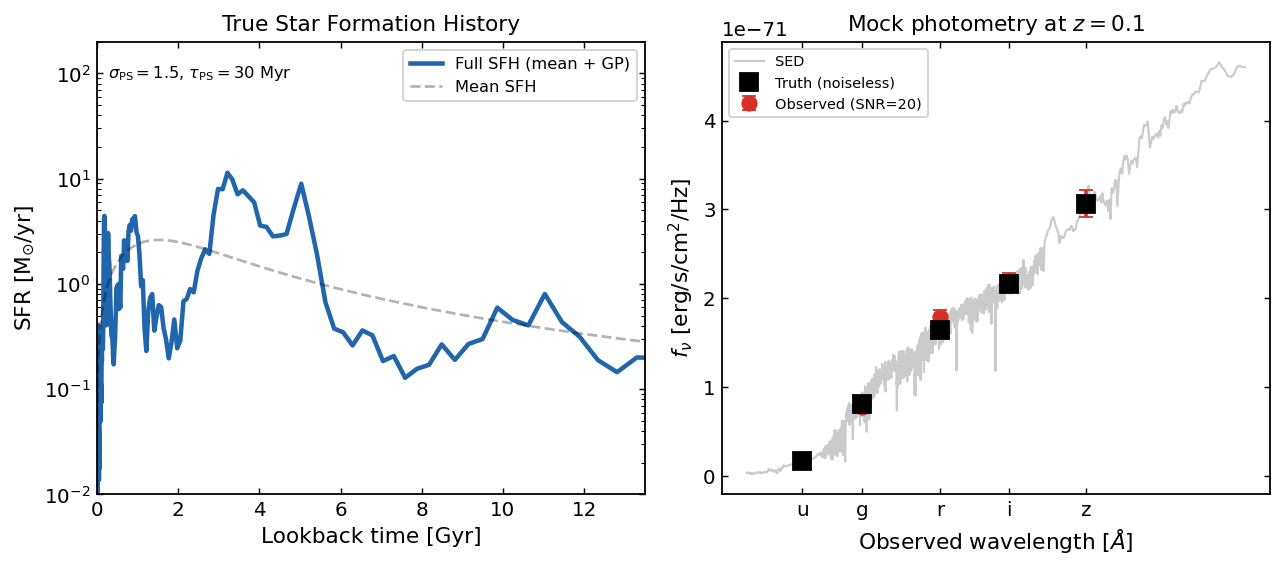

Redshift: z = 0.1
At SNR=20, the 5-band photometry has ~5% uncertainties per band.
The SED (gray) shows what a spectrograph would measure.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ---- Left panel: Star Formation History ----
ax = axes[0]
ax.plot(age_gyr, sfr, color="#2166ac", lw=2.5, label="Full SFH (mean + GP)")
ax.plot(age_gyr, sfr_mean, "k--", lw=1.5, alpha=0.3, label="Mean SFH")
ax.set_xlabel("Lookback time [Gyr]", fontsize=12)
ax.set_ylabel(r"SFR [M$_{\odot}$/yr]", fontsize=12)
ax.set_title("True Star Formation History", fontsize=12)
ax.set_xlim(0, 13.5)
ax.set_yscale("log")
ax.set_ylim(0.01, 200)
ax.legend(fontsize=9)
ax.text(
    0.02, 0.95,
    f"$\\sigma_\\mathrm{{PS}}={params['sigma_ps']}$, "
    f"$\\tau_\\mathrm{{PS}}={params['tau_ps']/1e6:.0f}$ Myr",
    transform=ax.transAxes, fontsize=9, va="top",
)

# ---- Right panel: Photometry with SED background ----
ax = axes[1]
mask_obs = (wave_obs > 2500) & (wave_obs < 12000)
ax.plot(wave_obs[mask_obs], sed_obs[mask_obs],
        color="#999999", lw=1.2, alpha=0.5, label="SED", zorder=1)
ax.errorbar(
    band_centers_arr, mock["flux_obs"], yerr=mock["noise"],
    fmt="o", ms=8, capsize=4, color="#d73027", lw=2,
    label="Observed (SNR=20)", zorder=5,
)
ax.plot(band_centers_arr, mock["flux_true"],
        "ks", ms=10, zorder=10, label="Truth (noiseless)")
ax.set_xlabel(r"Observed wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=12)
ax.set_title(f"Mock photometry at $z = {z}$", fontsize=12)
ax.set_xticks(band_centers_arr)
ax.set_xticklabels(band_names, fontsize=11)
ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("figures/03_single_mock.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Redshift: z = {z}")
print(f"At SNR=20, the 5-band photometry has ~5% uncertainties per band.")
print(f"The SED (gray) shows what a spectrograph would measure.")

---
## 2. Effect of Signal-to-Noise Ratio

SNR determines how well physical parameters can be recovered from the photometry. SNR $= 5$ is typical for faint high-$z$ galaxies in JWST surveys; SNR $= 50$ is achievable for bright SDSS galaxies. At low SNR, the error bars are large and degenerate parameters (dust, metallicity) become unconstrained -- the SED shape is buried in noise. At high SNR, the photometric points tightly pin down the SED shape, enabling precise recovery of even weakly constrained parameters.

Below we show the same galaxy observed at five different SNR levels. The gray background SED provides context for where the filter measurements fall relative to the full spectral energy distribution.

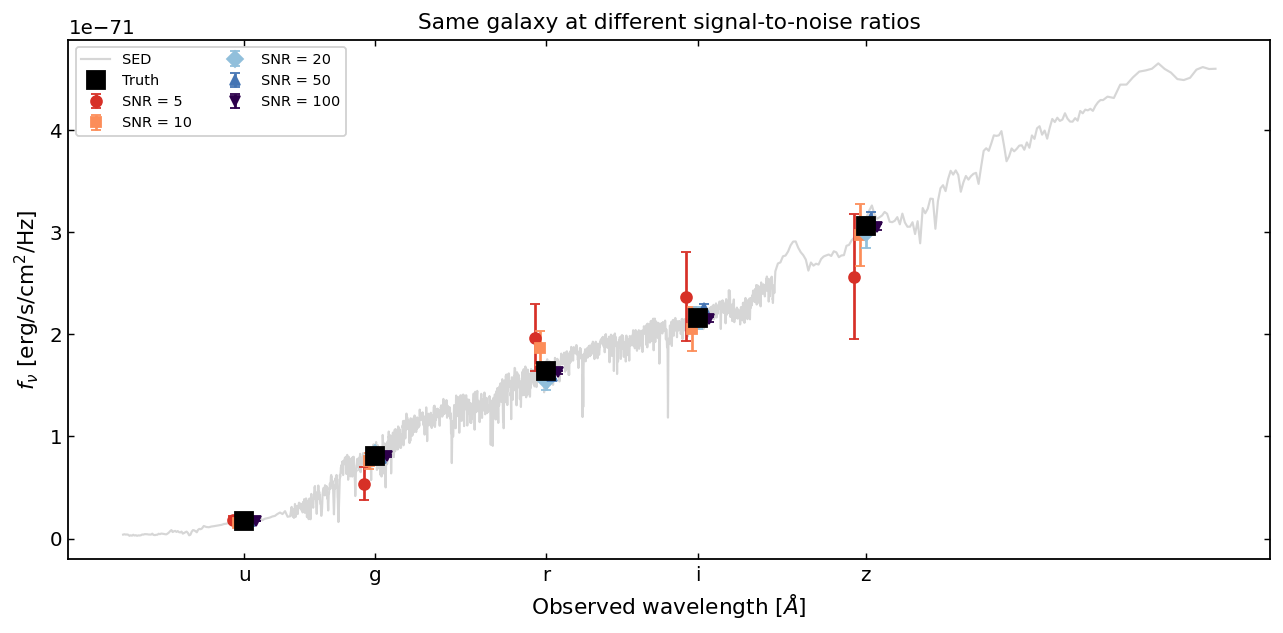

SNR=5: the u-band scatter is enormous -- dust and age are
nearly impossible to disentangle with 5-band photometry alone.
SNR=100: the SED shape is tightly constrained.
Tutorials 4-5 will quantify how SNR affects parameter recovery.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

# Background SED
ax.plot(wave_obs[mask_obs], sed_obs[mask_obs],
        color="#999999", lw=1.2, alpha=0.4, zorder=0, label="SED")

# Mock photometry at different SNR values
snr_configs = [
    (5,   "#d73027", -100, "o"),
    (10,  "#fc8d59",  -50, "s"),
    (20,  "#91bfdb",    0, "D"),
    (50,  "#4575b4",   50, "^"),
    (100, "#2d004b",  100, "v"),
]

for snr, color, offset, marker in snr_configs:
    m = generate_mock(
        model, params,
        key=jax.random.PRNGKey(snr),
        snr=float(snr),
    )
    ax.errorbar(
        band_centers_arr + offset, m["flux_obs"], yerr=m["noise"],
        fmt=marker, ms=6, capsize=3, lw=1.5,
        color=color, label=f"SNR = {snr}", zorder=5,
    )

# Truth
ax.plot(band_centers_arr, mock["flux_true"],
        "ks", ms=10, zorder=10, label="Truth")

ax.set_xlabel(r"Observed wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=12)
ax.set_title("Same galaxy at different signal-to-noise ratios", fontsize=12)
ax.set_xticks(band_centers_arr)
ax.set_xticklabels(band_names, fontsize=11)
ax.legend(fontsize=8, ncol=2, loc="upper left")

plt.tight_layout()
plt.savefig("figures/03_snr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("SNR=5: the u-band scatter is enormous -- dust and age are")
print("nearly impossible to disentangle with 5-band photometry alone.")
print("SNR=100: the SED shape is tightly constrained.")
print("Tutorials 4-5 will quantify how SNR affects parameter recovery.")

---
## 3. A Zoo of Galaxy Types

Different galaxy types occupy different regions of parameter space. We create four archetypes spanning the key axes of variation: young/old, dusty/clean, and bursty/smooth. This tests that the forward model produces physically reasonable SEDs across the full range of galaxy properties.

The four archetypes are:

| Galaxy type | Key properties | Physical interpretation |
|-------------|---------------|------------------------|
| **Young starburst** | $\sigma_{\rm PS}=2.5$, $\tau_{\rm PS}=10$ Myr, low dust | Highly bursty, UV-bright, like local dwarf starbursts |
| **Cosmic noon SF** | $\sigma_{\rm PS}=1.5$, $\tau_{\rm PS}=50$ Myr, moderate dust | Typical $z \sim 2$ star-forming galaxy on the main sequence |
| **Dusty star-forming** | $\tau_{V,1}=4.0$, $\tau_{V,2}=1.5$ | Heavily obscured, UV-suppressed, like submillimeter galaxies |
| **Quiescent** | $\sigma_{\rm PS}=0.5$, $\alpha=3.0$, low dust | Smooth, declining SFH with a strong 4000 $\text{\AA}$ break |

In [5]:
galaxy_zoo = {
    "Young starburst": {
        "sigma_ps": 2.5, "tau_ps": 10e6,
        "alpha": 0.5, "beta": 2.0, "tau_sfh": 0.5e9, "sfr_norm": 20.0,
        "log_z": -1.0, "tau_v1": 0.5, "tau_v2": 0.1, "dust_n": -0.7,
        "color": "#2166ac", "ls": "-",
    },
    "Cosmic noon SF": {
        "sigma_ps": 1.5, "tau_ps": 50e6,
        "alpha": 1.5, "beta": 0.8, "tau_sfh": 2e9, "sfr_norm": 10.0,
        "log_z": -0.5, "tau_v1": 1.5, "tau_v2": 0.5, "dust_n": -0.7,
        "color": "#67a9cf", "ls": "-",
    },
    "Dusty star-forming": {
        "sigma_ps": 1.0, "tau_ps": 30e6,
        "alpha": 1.0, "beta": 1.0, "tau_sfh": 3e9, "sfr_norm": 15.0,
        "log_z": -0.3, "tau_v1": 4.0, "tau_v2": 1.5, "dust_n": -0.7,
        "color": "#ef8a62", "ls": "-",
    },
    "Quiescent": {
        "sigma_ps": 0.5, "tau_ps": 200e6,
        "alpha": 3.0, "beta": 1.0, "tau_sfh": 5e9, "sfr_norm": 2.0,
        "log_z": -0.3, "tau_v1": 0.2, "tau_v2": 0.1, "dust_n": -0.7,
        "color": "#b2182b", "ls": "-",
    },
}

print("Galaxy archetypes defined:")
for name, gal in galaxy_zoo.items():
    print(f"  {name}: sigma_PS={gal['sigma_ps']}, "
          f"tau_PS={gal['tau_ps']/1e6:.0f} Myr, "
          f"tau_v1={gal['tau_v1']}, tau_v2={gal['tau_v2']}")

Galaxy archetypes defined:
  Young starburst: sigma_PS=2.5, tau_PS=10 Myr, tau_v1=0.5, tau_v2=0.1
  Cosmic noon SF: sigma_PS=1.5, tau_PS=50 Myr, tau_v1=1.5, tau_v2=0.5
  Dusty star-forming: sigma_PS=1.0, tau_PS=30 Myr, tau_v1=4.0, tau_v2=1.5
  Quiescent: sigma_PS=0.5, tau_PS=200 Myr, tau_v1=0.2, tau_v2=0.1


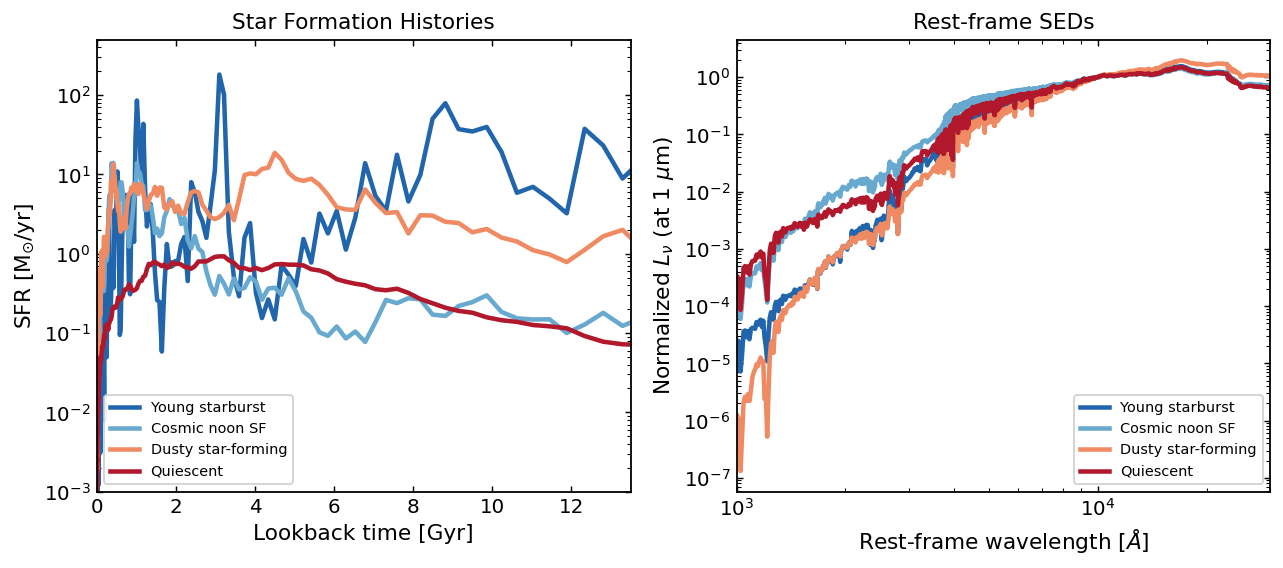

Young starburst: UV-bright, bursty SFH, steep blue UV slope.
Dusty SF: UV is heavily suppressed by tau_v1=4.0 birth-cloud dust.
Quiescent: red SED dominated by old stars, smooth declining SFH.
Cosmic noon SF: intermediate in all respects.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

wave_rest = ssp_data.ssp_wave
mask_sed = (wave_rest > 1000) & (wave_rest < 30000)
idx_1um = int(jnp.argmin(jnp.abs(wave_rest - 10000)))

for i, (name, gal) in enumerate(galaxy_zoo.items()):
    xi_i = jax.random.normal(jax.random.PRNGKey(i * 7), shape=(N_GRID,))
    p_i = {"xi": xi_i, **{k: v for k, v in gal.items()
                           if k not in ("color", "ls")}}

    # Compute SFH
    sfr_i = compute_sfh(p_i)
    axes[0].plot(age_gyr, sfr_i, lw=2.5, color=gal["color"], label=name)

    # Compute SED (rest-frame, normalized at 1 micron)
    sed_i = model(p_i)
    sed_norm = sed_i / sed_i[idx_1um]
    axes[1].plot(wave_rest[mask_sed], sed_norm[mask_sed],
                 lw=2.5, color=gal["color"], label=name)

# ---- Left: SFHs ----
ax = axes[0]
ax.set_xlabel("Lookback time [Gyr]", fontsize=12)
ax.set_ylabel(r"SFR [M$_{\odot}$/yr]", fontsize=12)
ax.set_title("Star Formation Histories", fontsize=12)
ax.set_xlim(0, 13.5)
ax.set_yscale("log")
ax.set_ylim(1e-3, 500)
ax.legend(fontsize=8, loc="lower left")

# ---- Right: SEDs ----
ax = axes[1]
ax.set_xlabel(r"Rest-frame wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"Normalized $L_\nu$ (at 1 $\mu$m)", fontsize=12)
ax.set_title("Rest-frame SEDs", fontsize=12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1000, 30000)
ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("figures/03_galaxy_zoo.png", dpi=150, bbox_inches="tight")
plt.show()

print("Young starburst: UV-bright, bursty SFH, steep blue UV slope.")
print("Dusty SF: UV is heavily suppressed by tau_v1=4.0 birth-cloud dust.")
print("Quiescent: red SED dominated by old stars, smooth declining SFH.")
print("Cosmic noon SF: intermediate in all respects.")

---
## 4. A Mock Population

For population-level tests, we draw parameters from broad priors and generate an ensemble of 20 galaxies. The resulting color-color diagram shows the expected diversity: blue star-forming galaxies in the lower-left, red quiescent galaxies in the upper-right, with burstier galaxies ($\sigma_{\rm PS} > 2$) scattering further from the mean locus. The SFH spaghetti plot on the right illustrates the enormous diversity in star formation histories that can arise from the GP + PSD model.

In [7]:
n_gal = 20
rng = np.random.default_rng(42)

pop_params = []
pop_fluxes = []
pop_sfhs = []

for i in range(n_gal):
    xi_i = jax.random.normal(jax.random.PRNGKey(i * 3 + 100), shape=(N_GRID,))
    p = {
        "xi": xi_i,
        "sigma_ps": rng.uniform(0.3, 3.0),
        "tau_ps": 10 ** rng.uniform(6.5, 8.5),   # 3 Myr -- 300 Myr
        "alpha": rng.uniform(0.3, 3.0),
        "beta": rng.uniform(0.3, 2.0),
        "tau_sfh": 10 ** rng.uniform(8.5, 10.0),  # 0.3 -- 10 Gyr
        "sfr_norm": 10 ** rng.uniform(-0.5, 1.5),  # 0.3 -- 30 Msun/yr
        "log_z": rng.uniform(-2.5, -1.3),
        "tau_v1": rng.uniform(0.0, 3.0),
        "tau_v2": rng.uniform(0.0, 1.0),
        "dust_n": -0.7,
    }
    pop_params.append(p)
    pop_fluxes.append(model.predict_photometry(p))
    pop_sfhs.append(compute_sfh(p))

pop_fluxes = jnp.stack(pop_fluxes)

# Compute u-g and g-r colors (AB magnitudes)
ug = -2.5 * jnp.log10(pop_fluxes[:, 0] / pop_fluxes[:, 1])
gr = -2.5 * jnp.log10(pop_fluxes[:, 1] / pop_fluxes[:, 2])
sigma_ps_vals = jnp.array([p["sigma_ps"] for p in pop_params])

print(f"Generated {n_gal} galaxies with random parameters.")
print(f"  sigma_PS range: {float(sigma_ps_vals.min()):.2f} -- "
      f"{float(sigma_ps_vals.max()):.2f}")
print(f"  u-g color range: {float(ug.min()):.2f} -- {float(ug.max()):.2f} mag")
print(f"  g-r color range: {float(gr.min()):.2f} -- {float(gr.max()):.2f} mag")

Generated 20 galaxies with random parameters.
  sigma_PS range: 0.36 -- 2.90
  u-g color range: 0.90 -- 1.94 mag
  g-r color range: 0.27 -- 1.10 mag


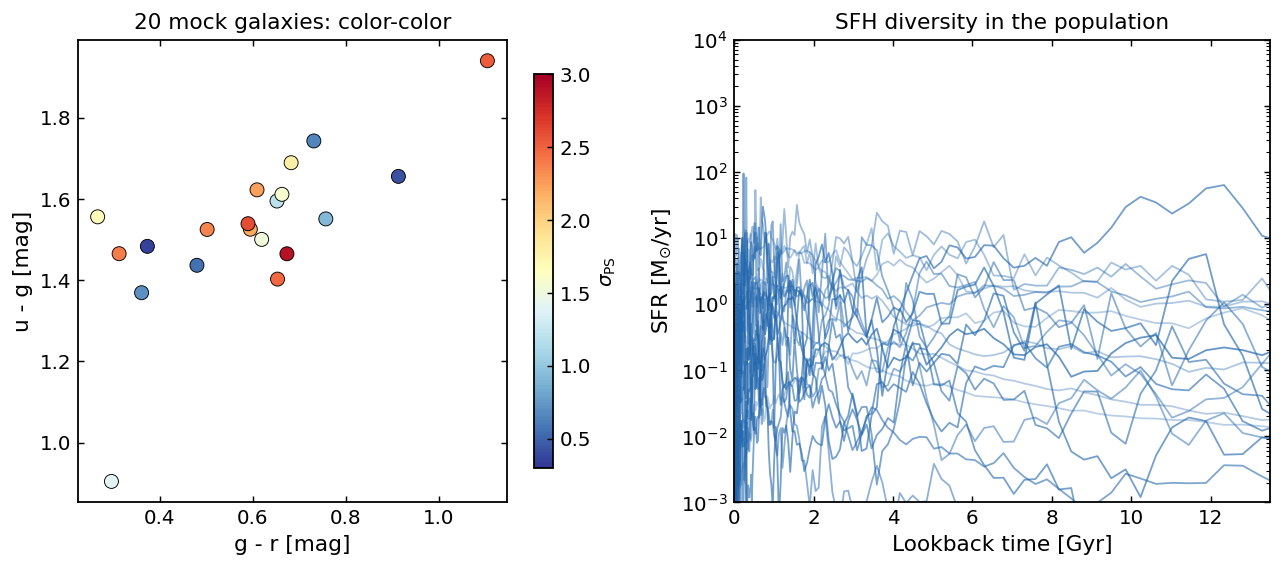

Burstier galaxies (red dots) scatter further in color-color space.
The SFH spaghetti plot shows the enormous diversity the GP model can produce.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ---- Left: color-color diagram ----
ax = axes[0]
sc = ax.scatter(
    gr, ug, c=sigma_ps_vals, cmap="RdYlBu_r",
    s=60, edgecolors="k", linewidths=0.5, zorder=5,
    vmin=0.3, vmax=3.0,
)
plt.colorbar(sc, ax=ax, label=r"$\sigma_{\rm PS}$", shrink=0.85)
ax.set_xlabel("g - r [mag]", fontsize=12)
ax.set_ylabel("u - g [mag]", fontsize=12)
ax.set_title(f"{n_gal} mock galaxies: color-color", fontsize=12)

# ---- Right: SFH spaghetti ----
ax = axes[1]
for i in range(n_gal):
    alpha_val = 0.3 + 0.4 * (float(sigma_ps_vals[i]) - 0.3) / 2.7
    ax.plot(age_gyr, pop_sfhs[i], alpha=alpha_val, lw=1.0, color="#2166ac")
ax.set_xlabel("Lookback time [Gyr]", fontsize=12)
ax.set_ylabel(r"SFR [M$_{\odot}$/yr]", fontsize=12)
ax.set_title("SFH diversity in the population", fontsize=12)
ax.set_xlim(0, 13.5)
ax.set_yscale("log")
ax.set_ylim(1e-3, 1e4)

plt.tight_layout()
plt.savefig("figures/03_mock_population.png", dpi=150, bbox_inches="tight")
plt.show()

print("Burstier galaxies (red dots) scatter further in color-color space.")
print("The SFH spaghetti plot shows the enormous diversity the GP model can produce.")

---
## 5. Mock Spectroscopy

Spectroscopy provides $\sim 200$ independent measurements per galaxy (vs 5 for broadband photometry), resolving individual spectral features like the 4000 $\text{\AA}$ break, Balmer absorption/emission lines, and forbidden-line emission. This dramatically improves parameter recovery -- especially for breaking the age-dust-metallicity degeneracy that plagues photometric SED fitting.

We generate a mock spectrum covering 4000--9000 $\text{\AA}$ in the observed frame at $z = 0.1$ with SNR $= 15$ per pixel. Key diagnostic features are labeled: the 4000 $\text{\AA}$ break (age/metallicity), H$\beta$ and H$\alpha$ (SFR and dust via the Balmer decrement), and [O III] $\lambda 5007$ (ionization and metallicity).

In [9]:
# ---- Generate mock spectrum ----
wave_spec = jnp.linspace(4000, 9000, 250)  # observed frame
spec_true = model.predict_spectrum(params, wave_spec)

# Add Gaussian noise at SNR=15 per pixel
snr_spec = 15.0
spec_noise = spec_true / snr_spec
key_spec = jax.random.PRNGKey(7)
spec_obs = spec_true + spec_noise * jax.random.normal(
    key_spec, shape=spec_true.shape
)

print(f"Spectrum: {len(wave_spec)} pixels, "
      f"{float(wave_spec[0]):.0f}--{float(wave_spec[-1]):.0f} Angstrom")
print(f"SNR per pixel: {snr_spec}")
print(f"Rest-frame coverage: {float(wave_spec[0])/(1+z):.0f}--"
      f"{float(wave_spec[-1])/(1+z):.0f} Angstrom")

Spectrum: 250 pixels, 4000--9000 Angstrom
SNR per pixel: 15.0
Rest-frame coverage: 3636--8182 Angstrom


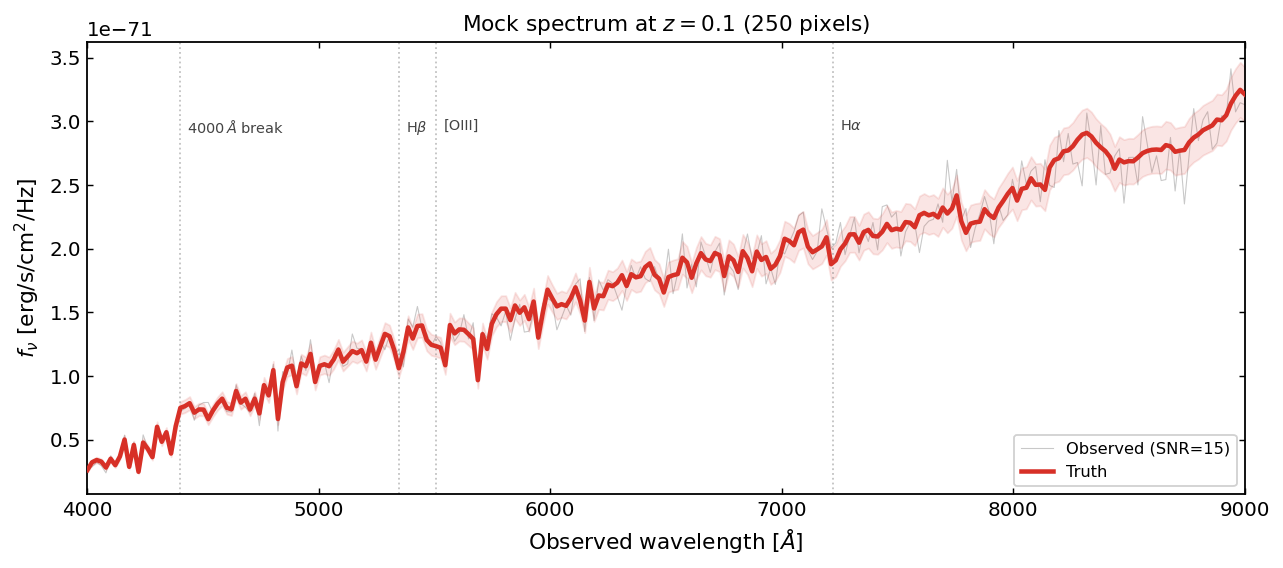

250 spectral pixels vs 5 photometric bands: a 50x increase
in independent measurements. The 4000 Angstrom break, Balmer
lines, and [OIII] each constrain different physical properties.


In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Noisy observed spectrum
ax.plot(wave_spec, spec_obs, color="#bbbbbb", lw=0.6, alpha=0.8,
        label=f"Observed (SNR={snr_spec:.0f})", zorder=1)

# Truth
ax.plot(wave_spec, spec_true, color="#d73027", lw=2.5,
        label="Truth", zorder=3)

# Noise envelope (1-sigma)
ax.fill_between(
    wave_spec, spec_true - spec_noise, spec_true + spec_noise,
    color="#d73027", alpha=0.12, zorder=2,
)

# ---- Label key spectral features ----
z = 0.1
features = [
    (4000 * (1 + z), r"4000$\,\AA$ break"),
    (4861 * (1 + z), r"H$\beta$"),
    (5007 * (1 + z), r"[OIII]"),
    (6563 * (1 + z), r"H$\alpha$"),
]
ymax = float(spec_true.max())
for wl, name in features:
    if float(wave_spec[0]) < wl < float(wave_spec[-1]):
        ax.axvline(wl, color="#666666", ls=":", alpha=0.4, lw=1)
        ax.text(wl + 30, ymax * 0.93, name,
                fontsize=8, color="#444444", ha="left", va="top")

ax.set_xlabel(r"Observed wavelength [$\AA$]", fontsize=12)
ax.set_ylabel(r"$f_\nu$ [erg/s/cm$^2$/Hz]", fontsize=12)
ax.set_title(f"Mock spectrum at $z = {z}$ (250 pixels)", fontsize=12)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(float(wave_spec[0]), float(wave_spec[-1]))

plt.tight_layout()
plt.savefig("figures/03_mock_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"250 spectral pixels vs 5 photometric bands: a 50x increase")
print(f"in independent measurements. The 4000 Angstrom break, Balmer")
print(f"lines, and [OIII] each constrain different physical properties.")

---
## Summary

This tutorial demonstrated the mock generation capabilities of `diffsed`. The key functions and their use cases are:

| Mock type | Use case | Key function |
|-----------|----------|-------------|
| Single galaxy | Parameter recovery tests | `generate_mock(model, params, key, snr)` |
| Different SNR | Forecast data requirements | Vary the `snr` argument |
| Galaxy zoo | Test across the full parameter space | Define archetype parameter dicts |
| Population | Ensemble statistics, color-color diagrams | Loop over random parameters |
| Spectroscopy | Test spectral fitting, break degeneracies | `model.predict_spectrum(params, wave_obs)` |

**Key takeaways:**

1. `generate_mock()` produces synthetic photometry with known ground truth -- essential for validating any fitting pipeline.
2. SNR strongly controls parameter recovery: at SNR $< 10$, degenerate parameters (dust, metallicity, age) are poorly constrained by 5-band photometry alone.
3. The GP + PSD model generates physically diverse SFHs spanning young starbursts to quiescent ellipticals.
4. Spectroscopy provides $\sim 50 \times$ more information than broadband photometry, resolving individual features that break the age-dust-metallicity degeneracy.

**Next:** [Tutorial 4: Fitting Mock Galaxies](04_fitting.ipynb) -- recovering parameters from the mocks generated here.

**Previous:** [Tutorial 2: From SFH to Observable SED](02_forward_model.ipynb)